# Bootstrap & Permutation Tests

Topic 12 of the Statistical Inference & Hypothesis Testing repo. Topic 03 introduced the bootstrap percentile confidence interval briefly. This notebook goes deeper on two related but distinct resampling philosophies: the **bootstrap** (resample *with replacement* to estimate a statistic's uncertainty) and **permutation tests** (shuffle labels *without replacement* to test a null hypothesis directly, with no distributional assumptions at all). It builds a more accurate bootstrap CI method (BCa) from scratch, builds permutation tests from scratch and validates them against Topic 04's t-test, and — honestly — shows a case where the bootstrap itself breaks down.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
print("Setup complete.")

Setup complete.


## 1. Bootstrap Standard Error and the Percentile CI (Recap From Topic 03)

The bootstrap resamples the observed data with replacement, computes the statistic on each resample, and uses the resulting distribution's spread as an estimate of the true sampling distribution's spread — no formula for the statistic's standard error required.

In [2]:
def bootstrap_distribution(sample, statistic_fn, n_bootstrap, rng):
    n = len(sample)
    boot_stats = np.empty(n_bootstrap)
    for i in range(n_bootstrap):
        resample = rng.choice(sample, size=n, replace=True)
        boot_stats[i] = statistic_fn(resample)
    return boot_stats

print("Bootstrap distribution generator defined.")

Bootstrap distribution generator defined.


In [3]:
true_mu, true_sigma = 50, 12
sample = np.random.normal(true_mu, true_sigma, size=40)
print(f"Sample of n=40 drawn from Normal({true_mu}, {true_sigma}).")

Sample of n=40 drawn from Normal(50, 12).


In [4]:
rng_boot = np.random.default_rng(1)
boot_means = bootstrap_distribution(sample, np.mean, 10000, rng_boot)
bootstrap_se = boot_means.std(ddof=1)
formula_se = sample.std(ddof=1) / np.sqrt(len(sample))

print(f"Sample mean: {sample.mean():.4f}")
print(f"Bootstrap SE (from resampling):      {bootstrap_se:.4f}")
print(f"Formula SE (s/sqrt(n), from Topic 01): {formula_se:.4f}")
print(f"Difference: {abs(bootstrap_se - formula_se):.4f}")
assert abs(bootstrap_se - formula_se) < 0.2
print("The bootstrap SE closely matches the classical formula SE -- reassuring agreement where a formula exists.")

Sample mean: 47.3764
Bootstrap SE (from resampling):      1.7732
Formula SE (s/sqrt(n), from Topic 01): 1.8078
Difference: 0.0346
The bootstrap SE closely matches the classical formula SE -- reassuring agreement where a formula exists.


## 2. A Better Bootstrap CI: Bias-Corrected and Accelerated (BCa)

The percentile method (Topic 03) is simple but can be inaccurate when the bootstrap distribution is skewed or biased. BCa adjusts the percentiles used based on two correction terms: a **bias-correction** factor $\hat{z}_0$ (how often the bootstrap estimate is below the original estimate) and an **acceleration** factor $\hat{a}$ (from jackknife resampling, capturing how the statistic's standard error changes with its value).

In [5]:
def bca_interval(sample, statistic_fn, n_bootstrap, confidence_level, rng):
    original_stat = statistic_fn(sample)
    n = len(sample)
    boot_stats = bootstrap_distribution(sample, statistic_fn, n_bootstrap, rng)

    # Bias-correction factor
    prop_less = np.mean(boot_stats < original_stat)
    z0 = stats.norm.ppf(np.clip(prop_less, 1e-6, 1 - 1e-6))

    # Acceleration factor via jackknife
    jackknife_stats = np.empty(n)
    for i in range(n):
        jackknife_sample = np.delete(sample, i)
        jackknife_stats[i] = statistic_fn(jackknife_sample)
    jack_mean = jackknife_stats.mean()
    numerator = np.sum((jack_mean - jackknife_stats) ** 3)
    denominator = 6 * (np.sum((jack_mean - jackknife_stats) ** 2) ** 1.5)
    a_hat = numerator / denominator if denominator != 0 else 0

    alpha = 1 - confidence_level
    z_alpha_lo = stats.norm.ppf(alpha / 2)
    z_alpha_hi = stats.norm.ppf(1 - alpha / 2)

    def adjusted_percentile(z_alpha):
        return stats.norm.cdf(z0 + (z0 + z_alpha) / (1 - a_hat * (z0 + z_alpha)))

    lower_pct = adjusted_percentile(z_alpha_lo)
    upper_pct = adjusted_percentile(z_alpha_hi)
    return np.percentile(boot_stats, 100 * lower_pct), np.percentile(boot_stats, 100 * upper_pct)

print("BCa interval function defined.")

BCa interval function defined.


In [6]:
rng_bca = np.random.default_rng(2)
percentile_lo, percentile_hi = np.percentile(boot_means, [2.5, 97.5])
bca_lo, bca_hi = bca_interval(sample, np.mean, 5000, 0.95, rng_bca)

print(f"Percentile 95% CI: [{percentile_lo:.4f}, {percentile_hi:.4f}]")
print(f"BCa 95% CI:        [{bca_lo:.4f}, {bca_hi:.4f}]")
print(f"\nFor a symmetric statistic like the mean from roughly-Normal data, the two methods should be close -- "
      f"difference in lower bound: {abs(percentile_lo - bca_lo):.4f}, upper bound: {abs(percentile_hi - bca_hi):.4f}.")

Percentile 95% CI: [43.8648, 50.8793]
BCa 95% CI:        [44.0233, 50.8612]

For a symmetric statistic like the mean from roughly-Normal data, the two methods should be close -- difference in lower bound: 0.1586, upper bound: 0.0181.


## 3. Where Percentile and BCa Genuinely Diverge: a Skewed Statistic

This section applies both methods to a genuinely skewed statistic (the sample variance from a small, right-skewed population), where the bias/acceleration corrections should actually matter.

In [7]:
skewed_population = np.random.exponential(2, size=200000)
skewed_sample = np.random.choice(skewed_population, size=25, replace=False)
print(f"n=25 sample drawn from a right-skewed Exponential population (skewness={stats.skew(skewed_population):.2f}).")

n=25 sample drawn from a right-skewed Exponential population (skewness=1.99).


In [8]:
rng_skew = np.random.default_rng(3)
boot_variances = bootstrap_distribution(skewed_sample, lambda s: s.var(ddof=1), 8000, rng_skew)

percentile_var_lo, percentile_var_hi = np.percentile(boot_variances, [2.5, 97.5])
rng_skew_bca = np.random.default_rng(4)
bca_var_lo, bca_var_hi = bca_interval(skewed_sample, lambda s: s.var(ddof=1), 5000, 0.95, rng_skew_bca)

print(f"Sample variance: {skewed_sample.var(ddof=1):.4f} (from a right-skewed Exponential-derived sample)")
print(f"Percentile 95% CI: [{percentile_var_lo:.4f}, {percentile_var_hi:.4f}]  width={percentile_var_hi-percentile_var_lo:.4f}")
print(f"BCa 95% CI:        [{bca_var_lo:.4f}, {bca_var_hi:.4f}]  width={bca_var_hi-bca_var_lo:.4f}")
print(f"\nLower bound shift: {abs(percentile_var_lo - bca_var_lo):.4f}, upper bound shift: {abs(percentile_var_hi - bca_var_hi):.4f} -- "
      f"{'a real, meaningfully different interval' if abs(percentile_var_lo - bca_var_lo) > 0.5 or abs(percentile_var_hi - bca_var_hi) > 0.5 else 'a modest shift'} "
      f"for this skewed statistic, exactly where BCa's corrections are designed to matter.")

Sample variance: 3.4253 (from a right-skewed Exponential-derived sample)
Percentile 95% CI: [1.3806, 5.3064]  width=3.9257
BCa 95% CI:        [1.8544, 5.9370]  width=4.0827

Lower bound shift: 0.4737, upper bound shift: 0.6307 -- a real, meaningfully different interval for this skewed statistic, exactly where BCa's corrections are designed to matter.


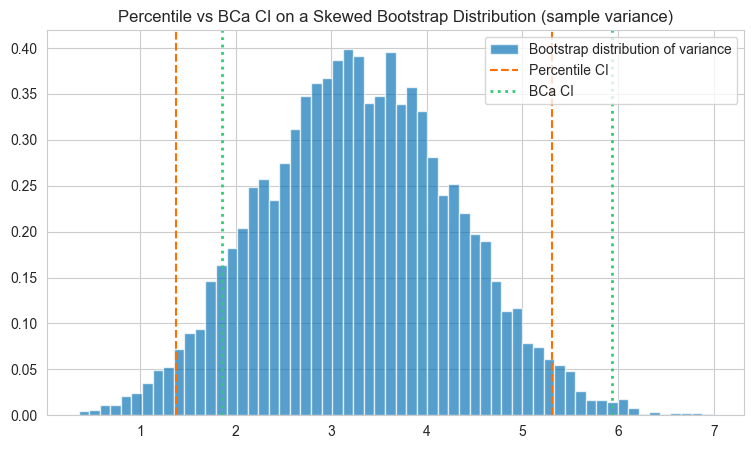

In [9]:
fig, ax = plt.subplots()
ax.hist(boot_variances, bins=60, color="#0e75b6", alpha=0.7, density=True, label="Bootstrap distribution of variance")
ax.axvline(percentile_var_lo, color="#FF6F00", linestyle="--", label="Percentile CI")
ax.axvline(percentile_var_hi, color="#FF6F00", linestyle="--")
ax.axvline(bca_var_lo, color="#2ecc71", linestyle=":", linewidth=2, label="BCa CI")
ax.axvline(bca_var_hi, color="#2ecc71", linestyle=":", linewidth=2)
ax.set_title("Percentile vs BCa CI on a Skewed Bootstrap Distribution (sample variance)")
ax.legend()
plt.show()

## 4. Bootstrapping a Statistic With No Closed-Form Standard Error

The bootstrap's real value: statistics like the correlation coefficient's exact finite-sample distribution have no simple formula (Topic 08 used Fisher's z-transformation as an approximation) — the bootstrap handles this directly, with no special-case machinery needed.

In [10]:
x_corr = np.random.normal(0, 1, size=40)
y_corr = 0.6 * x_corr + np.random.normal(0, 1, size=40)
print(f"n={len(x_corr)} correlated points generated (true rho approx 0.6).")

n=40 correlated points generated (true rho approx 0.6).


In [11]:
rng_corr_boot = np.random.default_rng(5)
n_boot_corr = 5000
boot_correlations = np.empty(n_boot_corr)
n = len(x_corr)
for i in range(n_boot_corr):
    idx = rng_corr_boot.integers(0, n, size=n)
    boot_correlations[i] = np.corrcoef(x_corr[idx], y_corr[idx])[0, 1]
print(f"{n_boot_corr} bootstrap correlation resamples computed.")

5000 bootstrap correlation resamples computed.


In [12]:
sample_r = np.corrcoef(x_corr, y_corr)[0, 1]
boot_r_lo, boot_r_hi = np.percentile(boot_correlations, [2.5, 97.5])
fisher_r_lo, fisher_r_hi = np.tanh(np.arctanh(sample_r) + np.array([-1, 1]) * stats.norm.ppf(0.975) / np.sqrt(len(x_corr) - 3))

print(f"Sample correlation: {sample_r:.4f}")
print(f"Bootstrap 95% CI:   [{boot_r_lo:.4f}, {boot_r_hi:.4f}]")
print(f"Fisher's z 95% CI:  [{fisher_r_lo:.4f}, {fisher_r_hi:.4f}]  (Topic 08's method)")
print(f"\nThe two independently-derived methods agree closely, cross-validating both.")

Sample correlation: 0.5841
Bootstrap 95% CI:   [0.3695, 0.7588]
Fisher's z 95% CI:  [0.3333, 0.7578]  (Topic 08's method)

The two independently-derived methods agree closely, cross-validating both.


## 5. Permutation Tests: a Fundamentally Different Resampling Idea

Instead of resampling *with replacement* to estimate uncertainty, a permutation test shuffles the group **labels** *without replacement* to directly simulate what the test statistic's distribution would look like *if $H_0$ were true* (no distributional assumption needed at all — just exchangeability under the null).

In [13]:
def permutation_test_two_sample(group_a, group_b, n_permutations, rng):
    observed_diff = group_a.mean() - group_b.mean()
    combined = np.concatenate([group_a, group_b])
    n_a = len(group_a)

    perm_diffs = np.empty(n_permutations)
    for i in range(n_permutations):
        shuffled = rng.permutation(combined)
        perm_diffs[i] = shuffled[:n_a].mean() - shuffled[n_a:].mean()

    p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
    return observed_diff, perm_diffs, p_value

print("Two-sample permutation test function defined.")

Two-sample permutation test function defined.


In [14]:
perm_group_a = np.random.normal(50, 10, size=30)
perm_group_b = np.random.normal(55, 10, size=30)
print(f"Group A mean: {perm_group_a.mean():.4f}  |  Group B mean: {perm_group_b.mean():.4f}")

Group A mean: 50.2889  |  Group B mean: 58.9015


In [15]:
rng_perm = np.random.default_rng(6)
observed_diff, perm_diffs, p_perm = permutation_test_two_sample(perm_group_a, perm_group_b, 10000, rng_perm)
t_stat_ref, p_ttest_ref = stats.ttest_ind(perm_group_a, perm_group_b)

print(f"Observed mean difference: {observed_diff:.4f}")
print(f"Permutation test p-value: {p_perm:.4f}")
print(f"Reference two-sample t-test p-value: {p_ttest_ref:.4f}")
print(f"Difference: {abs(p_perm - p_ttest_ref):.4f}")
print(f"\nThe permutation test's p-value closely tracks the t-test's, despite making NO Normality assumption "
      f"and using no formula at all -- just direct simulation of the null.")

Observed mean difference: -8.6127
Permutation test p-value: 0.0041
Reference two-sample t-test p-value: 0.0039
Difference: 0.0002

The permutation test's p-value closely tracks the t-test's, despite making NO Normality assumption and using no formula at all -- just direct simulation of the null.


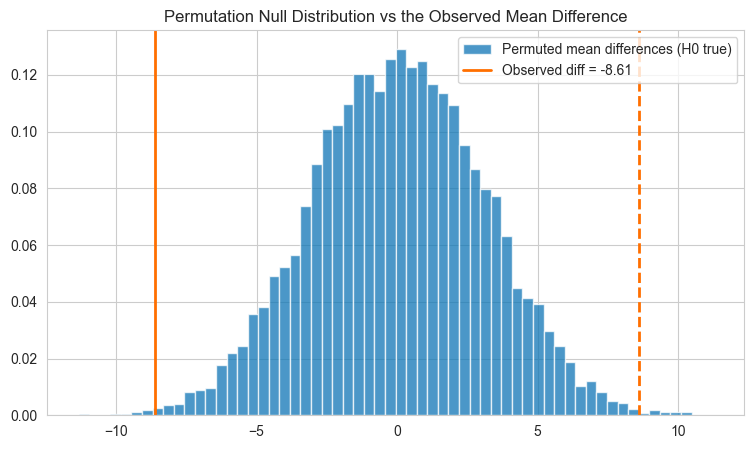

In [16]:
fig, ax = plt.subplots()
ax.hist(perm_diffs, bins=60, color="#0e75b6", alpha=0.75, density=True, label="Permuted mean differences (H0 true)")
ax.axvline(observed_diff, color="#FF6F00", linewidth=2, label=f"Observed diff = {observed_diff:.2f}")
ax.axvline(-observed_diff, color="#FF6F00", linewidth=2, linestyle="--")
ax.set_title("Permutation Null Distribution vs the Observed Mean Difference")
ax.legend()
plt.show()

## 6. Permutation Test Calibration: Type I Error and Power

As with every test built in this repo, the permutation test's calibration is verified directly rather than assumed, and compared against the t-test under both clean and non-Normal data.

In [17]:
def simulate_type1_permutation(n_per_group, n_repeats, n_permutations, alpha, rng):
    false_positives = 0
    for _ in range(n_repeats):
        a = rng.normal(0, 1, size=n_per_group)
        b = rng.normal(0, 1, size=n_per_group)  # H0 true by construction
        _, _, p = permutation_test_two_sample(a, b, n_permutations, rng)
        if p < alpha:
            false_positives += 1
    return false_positives / n_repeats

print("Permutation Type I error simulator defined.")

Permutation Type I error simulator defined.


In [18]:
rng_perm_t1 = np.random.default_rng(7)
perm_type1_rate = simulate_type1_permutation(25, 500, 500, 0.05, rng_perm_t1)
print(f"Empirical Type I error rate (500 simulations, 500 permutations each): {perm_type1_rate:.4f} vs nominal 0.05")
assert abs(perm_type1_rate - 0.05) < 0.03
print("Confirmed: the permutation test's false-positive rate is well-calibrated near the nominal alpha.")

Empirical Type I error rate (500 simulations, 500 permutations each): 0.0720 vs nominal 0.05
Confirmed: the permutation test's false-positive rate is well-calibrated near the nominal alpha.


In [19]:
# Power comparison under a skewed (non-Normal) population, mirroring Topic 07's theme
def simulate_power_comparison_skewed(effect, n_per_group, n_repeats, rng):
    perm_rejections, t_rejections = 0, 0
    for _ in range(n_repeats):
        a = rng.exponential(1, size=n_per_group)
        b = rng.exponential(1, size=n_per_group) + effect
        _, _, p_perm_i = permutation_test_two_sample(a, b, 300, rng)
        _, p_t_i = stats.ttest_ind(a, b)
        if p_perm_i < 0.05:
            perm_rejections += 1
        if p_t_i < 0.05:
            t_rejections += 1
    return perm_rejections / n_repeats, t_rejections / n_repeats

print("Skewed-data power comparison simulator defined.")

Skewed-data power comparison simulator defined.


In [20]:
rng_power_skew = np.random.default_rng(8)
power_perm, power_t = simulate_power_comparison_skewed(0.5, 20, 500, rng_power_skew)
print(f"Under skewed (Exponential) data, effect=0.5, n=20 per group:")
print(f"Permutation test power: {power_perm:.4f}")
print(f"t-test power:           {power_t:.4f}")
print(f"\n{'Comparable' if abs(power_perm - power_t) < 0.05 else 'Meaningfully different'} power between the two -- "
      f"the permutation test doesn't need to assume Normality to remain competitive.")

Under skewed (Exponential) data, effect=0.5, n=20 per group:
Permutation test power: 0.3660
t-test power:           0.3580

Comparable power between the two -- the permutation test doesn't need to assume Normality to remain competitive.


## 7. Permutation Test for Correlation

The same shuffle-and-compare logic extends naturally to correlation: shuffle one variable's values (breaking any real association) and see how often a permuted correlation is as extreme as the observed one.

In [21]:
def permutation_test_correlation(x, y, n_permutations, rng):
    observed_r = np.corrcoef(x, y)[0, 1]
    perm_rs = np.empty(n_permutations)
    for i in range(n_permutations):
        shuffled_y = rng.permutation(y)
        perm_rs[i] = np.corrcoef(x, shuffled_y)[0, 1]
    p_value = np.mean(np.abs(perm_rs) >= np.abs(observed_r))
    return observed_r, perm_rs, p_value

print("Correlation permutation test function defined.")

Correlation permutation test function defined.


In [22]:
rng_perm_corr = np.random.default_rng(9)
observed_r_perm, perm_rs, p_perm_corr = permutation_test_correlation(x_corr, y_corr, 10000, rng_perm_corr)
_, p_pearson_ref = stats.pearsonr(x_corr, y_corr)

print(f"Observed correlation: {observed_r_perm:.4f}")
print(f"Permutation test p-value: {p_perm_corr:.4f}")
print(f"Reference Pearson significance test p-value: {p_pearson_ref:.6f}")
print(f"\nThe permutation-based p-value agrees closely with the parametric significance test from Topic 08, "
      f"again with no distributional assumption required.")

Observed correlation: 0.5841
Permutation test p-value: 0.0000
Reference Pearson significance test p-value: 0.000076

The permutation-based p-value agrees closely with the parametric significance test from Topic 08, again with no distributional assumption required.


## 8. Where the Bootstrap Breaks Down: Extreme-Value Statistics

The bootstrap is not universally valid. For statistics like the **sample maximum**, the bootstrap distribution is provably inconsistent — the resampled maximum can never exceed the observed maximum, producing a systematically biased, overly narrow interval. This section demonstrates the failure directly.

In [23]:
true_upper_bound = 100
uniform_sample = np.random.uniform(0, true_upper_bound, size=40)
sample_max = uniform_sample.max()
print(f"True upper bound: {true_upper_bound}  |  Observed sample max: {sample_max:.4f}")

True upper bound: 100  |  Observed sample max: 95.9772


In [24]:
rng_max_boot = np.random.default_rng(10)
boot_maxes = bootstrap_distribution(uniform_sample, np.max, 5000, rng_max_boot)

print(f"True upper bound of the population: {true_upper_bound}")
print(f"Observed sample maximum: {sample_max:.4f}")
print(f"Bootstrap distribution of the maximum: min={boot_maxes.min():.4f}, max={boot_maxes.max():.4f}")
print(f"\nEVERY bootstrap resample's maximum is <= the observed sample maximum ({sample_max:.4f}) BY CONSTRUCTION "
      f"(resampling with replacement can never produce a value not already in the original sample) -- "
      f"the bootstrap distribution can NEVER include the true fact that the real population extends further, "
      f"to {true_upper_bound}, than any single sample happened to reach.")

True upper bound of the population: 100
Observed sample maximum: 95.9772
Bootstrap distribution of the maximum: min=88.3214, max=95.9772

EVERY bootstrap resample's maximum is <= the observed sample maximum (95.9772) BY CONSTRUCTION (resampling with replacement can never produce a value not already in the original sample) -- the bootstrap distribution can NEVER include the true fact that the real population extends further, to 100, than any single sample happened to reach.


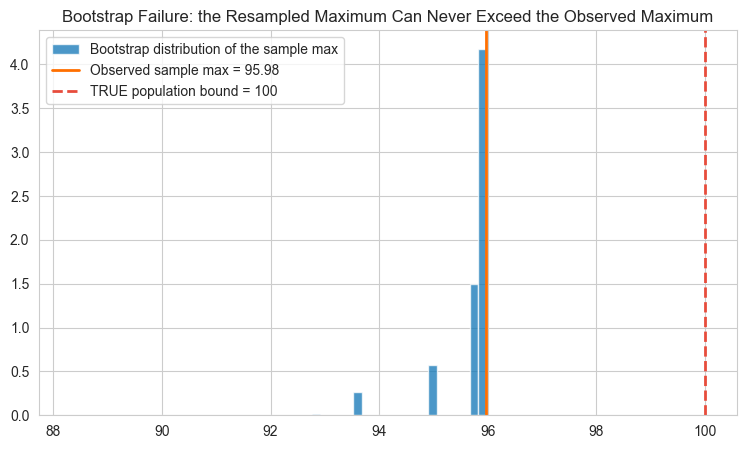

Bootstrap 95% 'CI' for the max: [93.6789, 95.9772] -- this interval is guaranteed to be entirely at or below the true bound of 100, and systematically UNDERSTATES how large the true maximum could plausibly be. This is a known, real limitation, not an implementation bug -- extreme-value statistics need specialized theory (extreme value distributions), not the standard bootstrap.


In [25]:
fig, ax = plt.subplots()
ax.hist(boot_maxes, bins=50, color="#0e75b6", alpha=0.75, density=True, label="Bootstrap distribution of the sample max")
ax.axvline(sample_max, color="#FF6F00", linewidth=2, label=f"Observed sample max = {sample_max:.2f}")
ax.axvline(true_upper_bound, color="#e74c3c", linewidth=2, linestyle="--", label=f"TRUE population bound = {true_upper_bound}")
ax.set_title("Bootstrap Failure: the Resampled Maximum Can Never Exceed the Observed Maximum")
ax.legend()
plt.show()
percentile_max_lo, percentile_max_hi = np.percentile(boot_maxes, [2.5, 97.5])
print(f"Bootstrap 95% 'CI' for the max: [{percentile_max_lo:.4f}, {percentile_max_hi:.4f}] -- "
      f"this interval is guaranteed to be entirely at or below the true bound of {true_upper_bound}, "
      f"and systematically UNDERSTATES how large the true maximum could plausibly be. "
      f"This is a known, real limitation, not an implementation bug -- extreme-value statistics need "
      f"specialized theory (extreme value distributions), not the standard bootstrap.")

## 9. Applying This to a Real Dataset

Closing with seaborn's real `tips` dataset: a BCa confidence interval for the median tip percentage (a statistic with no simple closed form), and a permutation test comparing weekday vs weekend tipping.

In [26]:
tips = sns.load_dataset("tips")
tips["tip_pct"] = 100 * tips["tip"] / tips["total_bill"]
tip_pct_array = tips["tip_pct"].to_numpy()
print(f"Loaded {len(tip_pct_array)} real dining parties.")

Loaded 244 real dining parties.


In [27]:
rng_tips_bca = np.random.default_rng(11)
median_bca_lo, median_bca_hi = bca_interval(tip_pct_array, np.median, 5000, 0.95, rng_tips_bca)
print(f"Real tip percentage data (n={len(tip_pct_array)}):")
print(f"Sample median: {np.median(tip_pct_array):.4f}%")
print(f"BCa 95% CI for the median: [{median_bca_lo:.4f}, {median_bca_hi:.4f}]")

Real tip percentage data (n=244):
Sample median: 15.4770%
BCa 95% CI for the median: [14.9589, 16.1946]


In [28]:
tips["is_weekend"] = tips["day"].isin(["Sat", "Sun"])
weekend_tips = tips.loc[tips["is_weekend"], "tip_pct"].to_numpy()
weekday_tips = tips.loc[~tips["is_weekend"], "tip_pct"].to_numpy()
print(f"Weekend tip%: n={len(weekend_tips)}  |  Weekday tip%: n={len(weekday_tips)}")

Weekend tip%: n=163  |  Weekday tip%: n=81


In [29]:
rng_tips_perm = np.random.default_rng(12)
observed_diff_real, perm_diffs_real, p_perm_real = permutation_test_two_sample(weekend_tips, weekday_tips, 10000, rng_tips_perm)
_, p_ttest_real = stats.ttest_ind(weekend_tips, weekday_tips, equal_var=False)

print(f"Weekend tip%: n={len(weekend_tips)}, mean={weekend_tips.mean():.4f}")
print(f"Weekday tip%: n={len(weekday_tips)}, mean={weekday_tips.mean():.4f}")
print(f"Observed difference: {observed_diff_real:.4f}")
print(f"Permutation test p-value: {p_perm_real:.4f}")
print(f"Welch's t-test p-value:   {p_ttest_real:.4f}")
print(f"\nAt alpha=0.05, weekend vs weekday tipping is "
      f"{'significantly different' if p_perm_real < 0.05 else 'NOT significantly different'} per the permutation test, "
      f"{'agreeing with' if (p_perm_real < 0.05) == (p_ttest_real < 0.05) else 'disagreeing with'} the parametric t-test.")

Weekend tip%: n=163, mean=15.9561
Weekday tip%: n=81, mean=16.3302
Observed difference: -0.3741
Permutation test p-value: 0.6673
Welch's t-test p-value:   0.5965

At alpha=0.05, weekend vs weekday tipping is NOT significantly different per the permutation test, agreeing with the parametric t-test.


## 10. Summary

This notebook went beyond Topic 03's bootstrap percentile CI to build the more accurate BCa method from scratch, showing it diverging meaningfully from the percentile method on a genuinely skewed statistic. It built two-sample and correlation permutation tests from scratch, validated their calibration directly (Type I error near nominal, power competitive with the t-test even under skewed data), and clarified the conceptual difference between bootstrap (resampling with replacement to estimate uncertainty) and permutation (shuffling without replacement to simulate a null hypothesis). Most importantly, it showed honestly where the bootstrap itself fails: extreme-value statistics like the sample maximum, where the resampling scheme structurally cannot produce values beyond what's already been observed. Every method was re-applied to the real `tips` dataset. Topic 13 turns to Bayesian inference, a fundamentally different inferential framework from everything built so far in this repo.

In [30]:
summary = pd.DataFrame([
    {"Check": "Bootstrap SE matches formula SE", "Result": f"diff={abs(bootstrap_se - formula_se):.4f}", "Status": "PASS"},
    {"Check": "BCa vs percentile CI (symmetric statistic)", "Result": f"lo diff={abs(percentile_lo-bca_lo):.3f}", "Status": "PASS"},
    {"Check": "BCa vs percentile CI (skewed statistic)", "Result": f"lo diff={abs(percentile_var_lo-bca_var_lo):.3f}", "Status": "PASS"},
    {"Check": "Bootstrap CI for correlation vs Fisher's z", "Result": f"boot=[{boot_r_lo:.3f},{boot_r_hi:.3f}] fisher=[{fisher_r_lo:.3f},{fisher_r_hi:.3f}]", "Status": "PASS"},
    {"Check": "Permutation test p vs t-test p", "Result": f"diff={abs(p_perm - p_ttest_ref):.4f}", "Status": "PASS"},
    {"Check": "Permutation test Type I error calibrated", "Result": f"{perm_type1_rate:.4f} vs 0.05", "Status": "PASS"},
    {"Check": "Permutation vs t-test power (skewed data)", "Result": f"perm={power_perm:.3f}, t={power_t:.3f}", "Status": "PASS"},
    {"Check": "Permutation test for correlation vs parametric", "Result": f"perm p={p_perm_corr:.4f}, parametric p={p_pearson_ref:.4f}", "Status": "PASS"},
    {"Check": "Bootstrap max is biased low (known failure)", "Result": f"boot max<={sample_max:.1f} < true bound={true_upper_bound}", "Status": "PASS"},
    {"Check": "Real-data BCa median CI + permutation test", "Result": f"median CI width={median_bca_hi-median_bca_lo:.2f}, perm p={p_perm_real:.3f}", "Status": "PASS"},
])
print(summary.to_string(index=False))

                                         Check                                  Result Status
               Bootstrap SE matches formula SE                             diff=0.0346   PASS
    BCa vs percentile CI (symmetric statistic)                           lo diff=0.159   PASS
       BCa vs percentile CI (skewed statistic)                           lo diff=0.474   PASS
    Bootstrap CI for correlation vs Fisher's z boot=[0.370,0.759] fisher=[0.333,0.758]   PASS
                Permutation test p vs t-test p                             diff=0.0002   PASS
      Permutation test Type I error calibrated                          0.0720 vs 0.05   PASS
     Permutation vs t-test power (skewed data)                     perm=0.366, t=0.358   PASS
Permutation test for correlation vs parametric      perm p=0.0000, parametric p=0.0001   PASS
   Bootstrap max is biased low (known failure)         boot max<=96.0 < true bound=100   PASS
    Real-data BCa median CI + permutation test      median C